# **3.2.1 Maximum-Flow Algorithm**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1lpkPKLa0HLSaKwubH_GbXP8xqT5H56k9?usp=sharing)

### 3.2.1 Maximum Flow Algorithm

Initialization: Establish an initial feasible flow.

&nbsp;&nbsp;&nbsp;&nbsp;*Phase 1:* Use a labeling procedure to look for a flow augmenting path. If none can be found, stop; the current flow is optimal.

&nbsp;&nbsp;&nbsp;&nbsp;*Phase 2:* Increase the current flow as much as possible in the flow augmenting path until some arc reaches its capacity.

The search for a flow augmenting path in Phase 1 is facilitated by a labeling procedure that begins by labeling the source node. We will use a check mark (✓) on our figures to indicate that a node has been labeled. From any labeled node i, we must examine outgoing arcs (i, j) and incoming arcs (j, i), for unlabeled nodes j. We label a (✓) node j if the current flow in outgoing arc (i, j) is less than its capacity uᵢⱼ, or if the current flow in incoming arc (j, i) is greater than zero. Labeling a node j means that we could increase the total flow in the network from the source as far as node j. If the sink node eventually can be labeled, then a flow augmenting path has been found. If more than one flow augmenting path exists, choose any one arbitrarily.

&nbsp;&nbsp;&nbsp;&nbsp;In Phase 2, the arcs in the flow augmenting path are first identified. Then by examining the differences in current flow and capacity flow on all forward arcs in the path, and the current flow in all backward arcs, we determine the greatest feasible amount by which the total flow through this path can be increased. Increase the flow in all forward arcs by this amount, and decrease the flow in all backward arcs by this amount.

&nbsp;&nbsp;&nbsp;&nbsp;We will now illustrate the maximum flow algorithm by applying it to the network pictured in Figure 3.4. Let us assume initially that the flow in all arcs is zero, xᵢⱼ = 0 and f = 0. In the first iteration, we label nodes A, B, C, D, and G, and discover the flow augmenting path (A, D), D, (D, G), across which we can increase the flow by 4. So now, xₐᴅ = 4, xᴅɢ = 4, and f = 4.

&nbsp;&nbsp;&nbsp;&nbsp;In the second iteration, we label nodes A, B, C, then nodes E, D, and F, and finally node G. A flow augmenting path consists of links (A, B), (B, D), (D, E), and (E, G), and flow on this path can be increased by 4. Now xₐᴮ = 4, xᴮᴰ = 4, xᴅᴱ = 4, xᴱɢ = 4, and f = 8.

&nbsp;&nbsp;&nbsp;&nbsp;In the third iteration, we see that there remains some unused capacity on link (A, B), so we can label nodes A, B, and E, but not G. It appears we cannot use the full capacity of link (A, B). However, we can also label nodes C, D, F, and G, and augment the flow along the links (A, D), (D, F), and (F, G) by 2, the amount of remaining capacity in (A, D). Now xₐᴅ = 6, xᴅꜰ = 2, xꜰɢ = 2, and f = 10.

&nbsp;&nbsp;&nbsp;&nbsp;In the fourth iteration, we can label nodes A, B, C, D, F, and G. Along the path from A, C, D, F, to G, we can add a flow of 4, the remaining capacity in (F, G). So xₐᴄ = 4, xᴄᴰ = 4, xᴅꜰ = 6, and f = 14.

&nbsp;&nbsp;&nbsp;&nbsp;In the fifth iteration, we can label all nodes except G. Therefore, there is no flow augmenting path, and the current flow of 14 is optimal.

&nbsp;&nbsp;&nbsp;&nbsp;Notice that in any network, there is always a bottleneck that in some sense impedes the flow through the network. The total capacity of the bottleneck is an upper bound on the total flow in the network. Cut sets are, by definition, essential in order for there to be a flow from source to sink, since removal of the cut set links would render the sink unreachable from the source. The capacities on the links in any cut set potentially limit the total flow. One of the fundamental theorems of Ford and Fulkerson states that the minimum cut, that is, the cut set with minimum total capacity, is in fact the bottleneck that precisely determines the maximum possible flow in the network. This *Max-Flow Min-Cut Theorem* provides the foundation for the maximum flow labeling algorithm presented earlier. During Phase 1 of the algorithm, if a flow augmenting path cannot be found, then we can be assured that the capacity of some cut is being fully used by the current flow. This minimum cut is the set of links that separate the nodes that are labeled (✓) from those that are not labeled. Observe that, by definition of the labeling algorithm, every forward arc in the cut set, from a labeled to an unlabeled node, must be at capacity. Similarly, every reverse arc in the cut set, from an unlabeled to a labeled node, must have zero flow. Therefore, the capacity of the cut is precisely equal to the current flow, and this flow is optimal. In other words, a saturated cut defines the maximum flow.

&nbsp;&nbsp;&nbsp;&nbsp;In the final iteration of the example earlier, the cut set that separates the labeled nodes from the unlabeled nodes is the set of links (E, G), (D, G), and (F, G). The capacity of this cut set is 4 + 4 + 6 = 14, which is just exactly the value of the optimal flow through this network.

&nbsp;&nbsp;&nbsp;&nbsp;If all of the arcs in a network are forward arcs, it is easy to identify a flow augmenting path. Each edge in the path is below capacity and we can increase the flow until some edge reaches capacity. To appreciate the idea of reverse arc labeling, consider the situation shown in Figure 3.5a. In the diagram, each arc from node i to node j is labeled with (xᵢⱼ, uᵢⱼ). Suppose our initial path is from node 1 to 2 to 4 to 6, with a flow of 4. At this point, shown in Figure 3.5b, there is no direct path from the source node 1 to the sink node 6 that allows an increase in flow. However, the algorithm will find the path
<br>
<br>


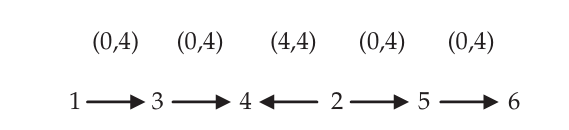
<p align="center">
  <img src="../Images/image.png" width="400">
</p>




Increase the flow on each forward arc by 4, and decrease the flow on the reverse arc. The resulting flow is shown in **Figure 3.5c** with a total flow of 8. Notice that the net effect,

<br>
<br>

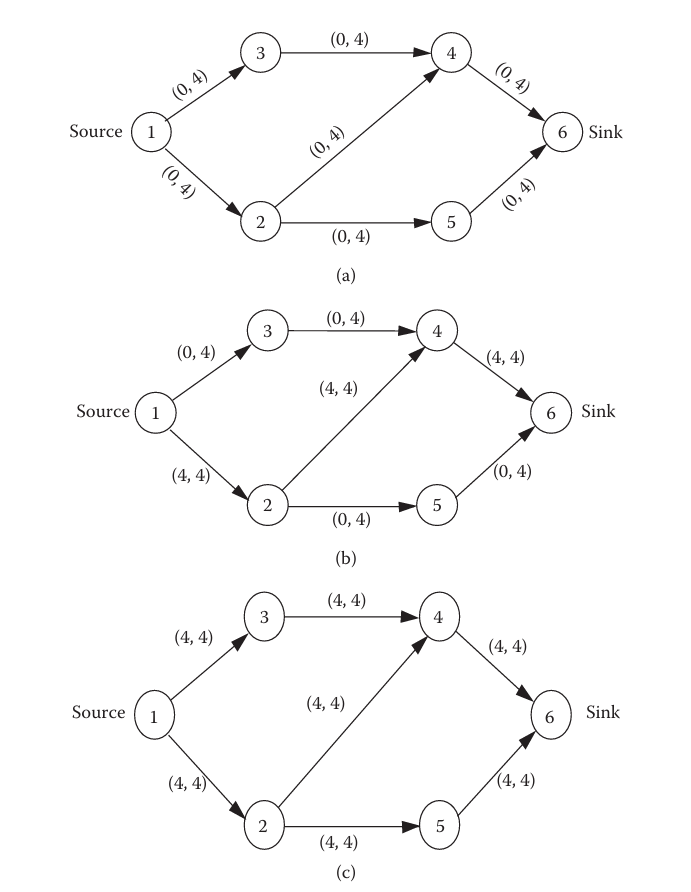
<p align="center">
  <img src="../Images/figure3.5c.png" width="500">
</p>


**FIGURE 3.5**<br>
Maximum flow example: (a) original network, (b) path augmenting, and (c) optimal maximum flow.
<br>
<br>

with respect to the reverse arc, is that we decided to take the flow out of node 2 and send it somewhere else (namely to nodes 5 and 6). Similarly, we decided to use the new flow at node 4, coming from node 3, instead of the flow from node 2. Therefore, if we can label node 4, we can effectively divert the flow at node 2 to create additional flow through the entire network.

In [ ]:
# ========================================
# 3.2.1 Maximum Flow Algorithm
# Clean Notebook Version
# Book Example + LP Method + Custom Network Tool
# ========================================

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    from scipy.optimize import linprog
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

print("Libraries loaded successfully.")
print("NetworkX version:", nx.__version__)


Libraries loaded successfully.
NetworkX version: 3.6.1


In [ ]:
G = nx.DiGraph()

G.add_edge('A', 'B', capacity=5)
G.add_edge('A', 'D', capacity=6)
G.add_edge('A', 'C', capacity=8)
G.add_edge('B', 'E', capacity=10)
G.add_edge('B', 'D', capacity=4)
G.add_edge('C', 'D', capacity=4)
G.add_edge('C', 'F', capacity=8)
G.add_edge('D', 'E', capacity=6)
G.add_edge('D', 'F', capacity=5)
G.add_edge('D', 'G', capacity=4)
G.add_edge('E', 'G', capacity=4)
G.add_edge('F', 'G', capacity=6)

flow_value, flow_dict = nx.maximum_flow(G, 'A', 'G')
print("Max flow:", flow_value)

Max flow: 14


In [ ]:
# ========================================
# Figure 3.4 — Book Example Network
# Maximum Flow from A to G
# ========================================

arc_table = [
    ("A", "B", 5),
    ("A", "D", 6),
    ("A", "C", 8),

    ("B", "E", 10),
    ("B", "D", 4),

    ("C", "D", 4),
    ("C", "F", 8),

    ("D", "E", 6),
    ("D", "F", 5),
    ("D", "G", 4),

    ("E", "G", 4),
    ("F", "G", 6),
]

source = "A"
sink = "G"

G = nx.DiGraph()

for u, v, cap in arc_table:
    G.add_edge(u, v, capacity=cap)

capacity_table = pd.DataFrame(arc_table, columns=["From", "To", "Capacity"])

print("Figure 3.4 network created successfully.")
print(f"Source node: {source}")
print(f"Sink node: {sink}")

capacity_table


Figure 3.4 network created successfully.
Source node: A
Sink node: G


,From,To,Capacity
0,A,B,5
1,A,D,6
2,A,C,8
3,B,E,10
4,B,D,4
5,C,D,4
6,C,F,8
7,D,E,6
8,D,F,5
9,D,G,4


In [ ]:
# ========================================
# Algebraic Method: Linear Programming Formulation
# ========================================

if not SCIPY_AVAILABLE:
    print("SciPy is not installed. Run this first if needed:")
    print("!pip install scipy")
else:
    arcs = [(u, v) for u, v, cap in arc_table]
    capacities = [cap for u, v, cap in arc_table]

    num_arcs = len(arcs)
    f_index = num_arcs
    num_variables = num_arcs + 1

    # Objective:
    # linprog minimizes, so maximize f by minimizing -f.
    c = np.zeros(num_variables)
    c[f_index] = -1

    # Capacity constraints: x_ij <= capacity_ij
    A_ub = []
    b_ub = []

    for i, capacity in enumerate(capacities):
        row = np.zeros(num_variables)
        row[i] = 1
        A_ub.append(row)
        b_ub.append(capacity)

    # Flow balance constraints
    A_eq = []
    b_eq = []

    nodes = sorted(G.nodes())

    for node in nodes:
        row = np.zeros(num_variables)

        for i, (u, v) in enumerate(arcs):
            if u == node:
                row[i] += 1
            if v == node:
                row[i] -= 1

        if node == source:
            row[f_index] = -1
        elif node == sink:
            row[f_index] = 1

        A_eq.append(row)
        b_eq.append(0)

    bounds = [(0, None)] * num_variables

    lp_result = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=bounds,
        method="highs"
    )

    if lp_result.success:
        print("=== Linear Programming Solution ===")
        print(f"Maximum flow value: {lp_result.x[f_index]:.0f}")
        print(f"Textbook answer: 14   {'✓' if round(lp_result.x[f_index]) == 14 else '✗'}")

        lp_rows = []

        for i, (u, v) in enumerate(arcs):
            flow = lp_result.x[i]
            capacity = capacities[i]

            lp_rows.append({
                "From": u,
                "To": v,
                "LP Flow": round(flow, 6),
                "Capacity": capacity,
                "Flow / Capacity": f"{round(flow, 6):g}/{capacity:g}",
                "Used?": "Yes" if flow > 1e-9 else "No",
                "Saturated?": "Yes" if abs(flow - capacity) < 1e-9 else "No"
            })

        lp_table = pd.DataFrame(lp_rows)
        display(lp_table)
    else:
        print("Linear programming solution failed.")
        print(lp_result.message)


=== Linear Programming Solution ===
Maximum flow value: 14
Textbook answer: 14   ✓


,From,To,LP Flow,Capacity,Flow / Capacity,Used?,Saturated?
0,A,B,2.0,5,2/5,Yes,No
1,A,D,6.0,6,6/6,Yes,Yes
2,A,C,6.0,8,6/8,Yes,No
3,B,E,2.0,10,2/10,Yes,No
4,B,D,0.0,4,0/4,No,No
5,C,D,0.0,4,0/4,No,No
6,C,F,6.0,8,6/8,Yes,No
7,D,E,2.0,6,2/6,Yes,No
8,D,F,0.0,5,0/5,No,No
9,D,G,4.0,4,4/4,Yes,Yes


In [ ]:
# ========================================
# Professional Layout Functions
# ========================================

def fallback_layered_flow_layout(graph, source, sink):
    """
    Backup layout when Graphviz is unavailable.
    It places the source on the left, the sink on the right,
    and intermediate nodes in layers.
    """

    try:
        topo_order = list(nx.topological_sort(graph))
        levels = {node: 0 for node in topo_order}

        for node in topo_order:
            for successor in graph.successors(node):
                levels[successor] = max(levels[successor], levels[node] + 1)

    except nx.NetworkXUnfeasible:
        try:
            levels = dict(nx.shortest_path_length(graph, source=source))
        except Exception:
            levels = {node: 0 for node in graph.nodes()}

    max_level = max(levels.values()) if levels else 0

    for node in graph.nodes():
        if node not in levels:
            levels[node] = max_level + 1

    levels[source] = 0
    levels[sink] = max(levels.values()) + 1

    level_groups = {}

    for node, level in levels.items():
        level_groups.setdefault(level, []).append(node)

    pos = {}

    for level in sorted(level_groups):
        nodes = sorted(level_groups[level])
        n = len(nodes)

        for i, node in enumerate(nodes):
            x = level
            y = (n - 1) / 2 - i
            pos[node] = (x, y)

    return pos


def graphviz_flow_layout(graph, source, sink):
    """
    Professional automatic layout for directed flow networks.
    Uses Graphviz DOT when available.
    If Graphviz is unavailable, it silently uses the fallback layout.
    """

    try:
        from networkx.drawing.nx_pydot import graphviz_layout

        H = graph.copy()

        H.graph["graph"] = {
            "rankdir": "LR",
            "nodesep": "0.75",
            "ranksep": "1.15",
            "splines": "true"
        }

        pos = graphviz_layout(H, prog="dot")

        xs = [p[0] for p in pos.values()]
        ys = [p[1] for p in pos.values()]

        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)

        width = max(max_x - min_x, 1)
        height = max(max_y - min_y, 1)

        normalized_pos = {}

        for node, (x, y) in pos.items():
            normalized_pos[node] = (
                5 * (x - min_x) / width,
                3 * (y - min_y) / height
            )

        return normalized_pos

    except Exception:
        return fallback_layered_flow_layout(graph, source, sink)


In [ ]:
# =================================
# Professional Drawing Function
# =================================

def draw_max_flow_network(
    graph,
    flow_dict,
    flow_value=None,
    title="Maximum Flow Network",
    pos=None,
    source=None,
    sink=None,
    node_size=800,
    figsize=None,
    curved_edges=True
):
    """
    Draws a maximum flow network using flow/capacity labels.

    Red arcs carry positive flow.
    Light gray arcs carry zero flow.
    """

    if pos is None:
        if source is not None and sink is not None:
            pos = graphviz_flow_layout(graph, source, sink)
        else:
            pos = nx.spring_layout(graph, seed=42)

    if figsize is None:
        number_of_nodes = graph.number_of_nodes()
        number_of_edges = graph.number_of_edges()
        width = max(10, min(18, 1.3 * number_of_nodes + 6))
        height = max(6, min(12, 0.45 * number_of_edges + 4))
        figsize = (width, height)

    fig, ax = plt.subplots(figsize=figsize)

    edge_labels = {}
    used_edges = []
    unused_edges = []

    for u, v, data in graph.edges(data=True):
        flow = flow_dict[u][v]
        capacity = data["capacity"]
        edge_labels[(u, v)] = f"{flow:g}/{capacity:g}"

        if flow > 0:
            used_edges.append((u, v))
        else:
            unused_edges.append((u, v))

    connection_style = "arc3,rad=0.05" if curved_edges else "arc3,rad=0.0"

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color="steelblue",
        node_size=node_size,
        linewidths=1.5,
        edgecolors="white",
        ax=ax
    )

    nx.draw_networkx_labels(
        graph,
        pos,
        font_color="white",
        font_weight="bold",
        font_size=12,
        ax=ax
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=unused_edges,
        edge_color="lightgray",
        width=2.0,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        min_source_margin=20,
        min_target_margin=20,
        connectionstyle=connection_style,
        ax=ax
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        edgelist=used_edges,
        edge_color="red",
        width=2.8,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22,
        min_source_margin=20,
        min_target_margin=20,
        connectionstyle=connection_style,
        ax=ax
    )

    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_size=9,
        label_pos=0.5,
        rotate=True,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.88, pad=0.2),
        ax=ax
    )

    if flow_value is not None:
        full_title = f"{title} = {flow_value:g}\nRed arcs carry flow, shown as flow/capacity"
    else:
        full_title = f"{title}\nRed arcs carry flow, shown as flow/capacity"

    ax.set_title(full_title, fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


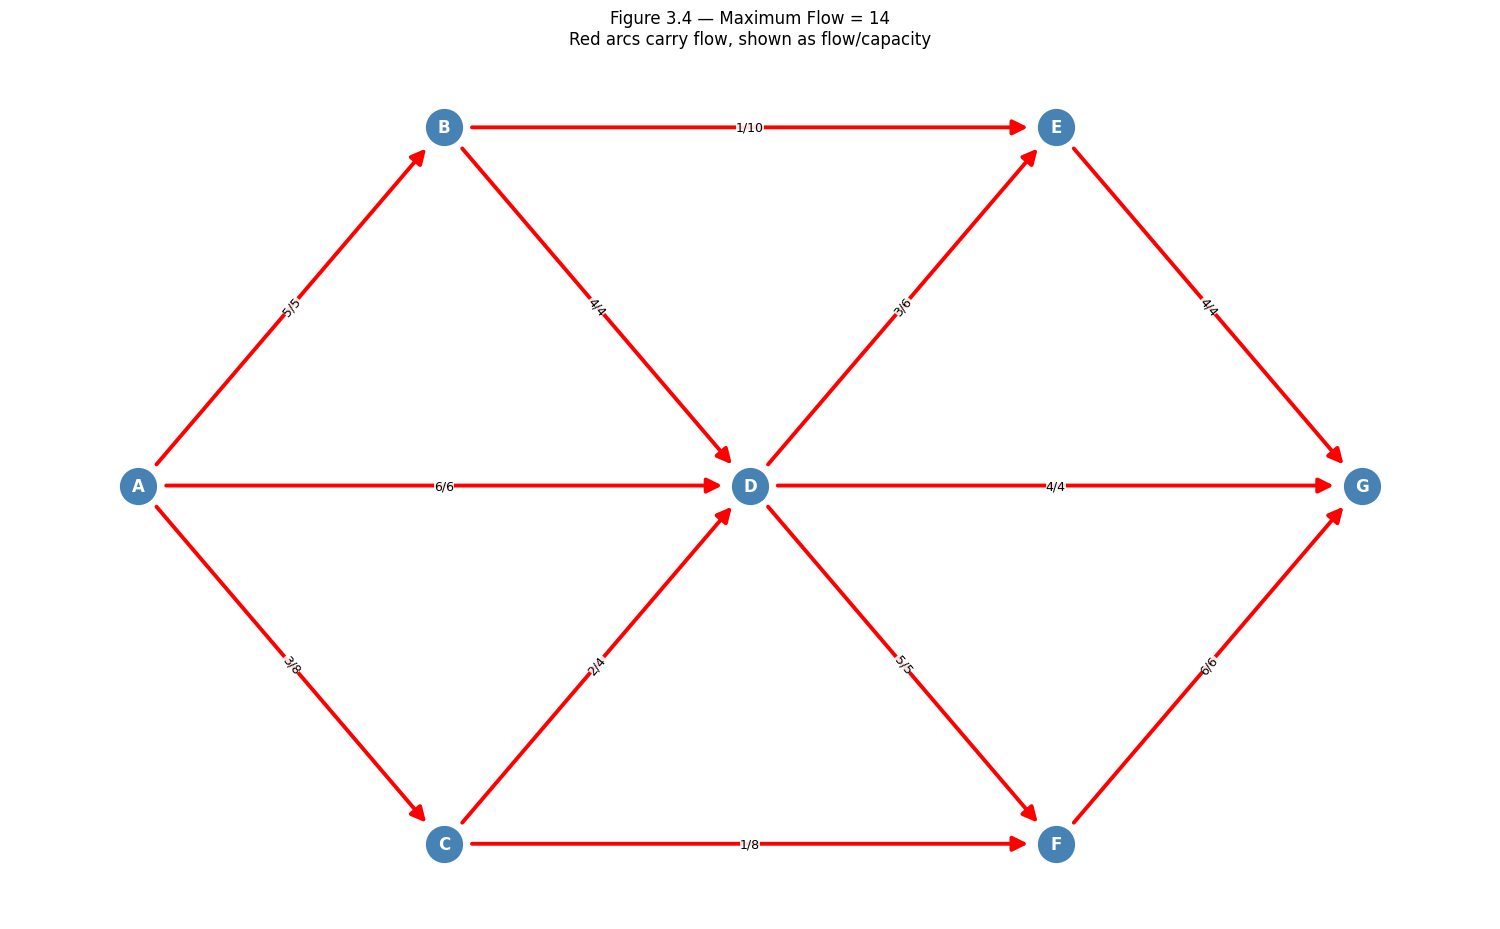

In [ ]:
# ========================================
# Draw Book Example Using Exact Book Layout
# ========================================

pos_book = {
    "A": (0, 1),
    "B": (1, 2),
    "C": (1, 0),
    "D": (2, 1),
    "E": (3, 2),
    "F": (3, 0),
    "G": (4, 1)
}

draw_max_flow_network(
    G,
    flow_dict,
    flow_value=flow_value,
    title="Figure 3.4 — Maximum Flow",
    pos=pos_book,
    curved_edges=False
)


In [ ]:
# ========================================
# Custom Maximum Flow Solver
# Main function for user-created networks.
# ========================================

def solve_and_draw_max_flow(custom_arc_table, custom_source, custom_sink, title="Custom Network — Maximum Flow"):
    """
    Solves and draws a maximum flow problem from a custom arc table.

    Example:
        custom_arc_table = [
            ("A", "B", 10),
            ("A", "C", 5),
            ("B", "D", 7)
        ]
    """

    custom_graph = nx.DiGraph()

    for u, v, cap in custom_arc_table:
        if cap < 0:
            raise ValueError(f"Capacity cannot be negative: ({u}, {v}, {cap})")
        custom_graph.add_edge(u, v, capacity=cap)

    if custom_source not in custom_graph.nodes:
        raise ValueError(f"Source node '{custom_source}' is not in the network.")

    if custom_sink not in custom_graph.nodes:
        raise ValueError(f"Sink node '{custom_sink}' is not in the network.")

    custom_flow_value, custom_flow_dict = nx.maximum_flow(
        custom_graph,
        custom_source,
        custom_sink
    )

    print("=== Custom Maximum Flow Result ===")
    print(f"Maximum flow from {custom_source} to {custom_sink}: {custom_flow_value:g}")

    rows = []

    for u, v, data in custom_graph.edges(data=True):
        flow = custom_flow_dict[u][v]
        capacity = data["capacity"]

        rows.append({
            "From": u,
            "To": v,
            "Flow": flow,
            "Capacity": capacity,
            "Flow / Capacity": f"{flow:g}/{capacity:g}",
            "Used?": "Yes" if flow > 0 else "No",
            "Saturated?": "Yes" if flow == capacity else "No"
        })

    result_table = pd.DataFrame(rows)
    display(result_table)

    draw_max_flow_network(
        custom_graph,
        custom_flow_dict,
        flow_value=custom_flow_value,
        title=title,
        source=custom_source,
        sink=custom_sink,
        curved_edges=True
    )

    return custom_flow_value, custom_flow_dict, result_table


Enter arcs in this format: StartNode, EndNode, Capacity
Example: A, B, 10
Type 'done' when finished.

Enter arc: A, B. 10
Invalid format. Please use: StartNode, EndNode, Capacity
Enter arc: A, B, 6
Enter arc: B, C, 9
Enter arc: C, D, 8
Enter arc: A, C, 7
Enter arc: done
Enter source node: A
Enter sink node: D
=== Custom Maximum Flow Result ===
Maximum flow from A to D: 8


,From,To,Flow,Capacity,Flow / Capacity,Used?,Saturated?
0,A,B,6.0,6.0,6/6,Yes,Yes
1,A,C,2.0,7.0,2/7,Yes,No
2,B,C,6.0,9.0,6/9,Yes,No
3,C,D,8.0,8.0,8/8,Yes,Yes


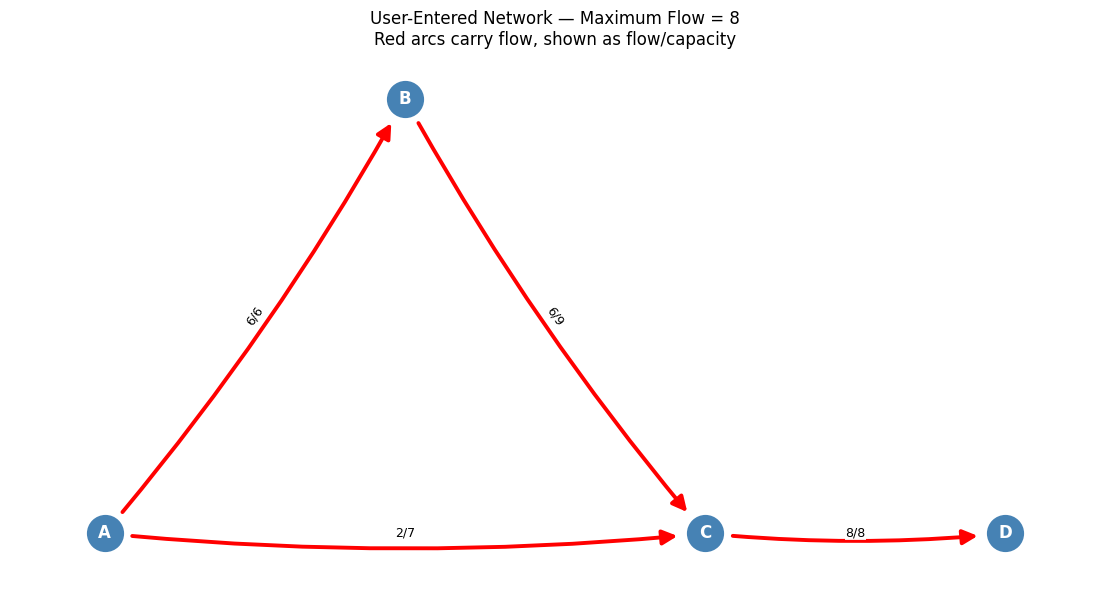

(8.0,
 {'A': {'B': 6.0, 'C': 2.0}, 'B': {'C': 6.0}, 'C': {'D': 8.0}, 'D': {}},
   From To  Flow  Capacity Flow / Capacity Used? Saturated?
 0    A  B   6.0       6.0             6/6   Yes        Yes
 1    A  C   2.0       7.0             2/7   Yes         No
 2    B  C   6.0       9.0             6/9   Yes         No
 3    C  D   8.0       8.0             8/8   Yes        Yes)

In [ ]:
# ========================================
# Optional: Fully Input-Based Version
# Run this only if you want users to type arcs manually.
# ========================================

def solve_max_flow_from_user_input():
    """
    Allows the user to type arcs manually.

    Format:
        A, B, 10

    Type:
        done

    Then enter source and sink.
    """

    print("Enter arcs in this format: StartNode, EndNode, Capacity")
    print("Example: A, B, 10")
    print("Type 'done' when finished.\n")

    entered_edges = []

    while True:
        user_input = input("Enter arc: ").strip()

        if user_input.lower() == "done":
            break

        try:
            u, v, cap = user_input.split(",")
            u = u.strip()
            v = v.strip()
            cap = float(cap.strip())

            if cap < 0:
                print("Capacity must be non-negative.")
                continue

            entered_edges.append((u, v, cap))

        except ValueError:
            print("Invalid format. Please use: StartNode, EndNode, Capacity")

    if not entered_edges:
        print("No arcs entered.")
        return None

    entered_source = input("Enter source node: ").strip()
    entered_sink = input("Enter sink node: ").strip()

    return solve_and_draw_max_flow(
        entered_edges,
        entered_source,
        entered_sink,
        title="User-Entered Network — Maximum Flow"
    )

# To use this version, remove the # from the next line and run the cell:
solve_max_flow_from_user_input()
